# Time Series Prediction with LSTM Using PyTorch

This notebook is a step-by-step tutorial on forecasting a univariate time series with an **LSTM** in PyTorch. Instead of building the LSTM cell from scratch (see `lstm_step_by_step.ipynb` for that), here you'll use PyTorch's built-in `nn.LSTM` on a real dataset. By the end you'll be able to:

* Turn a raw time series into supervised learning samples with a **sliding window**
* Scale the data and split it into train / test sets **without shuffling** (order matters in time series!)
* Build a small LSTM regressor with `nn.LSTM` + `nn.Linear` and understand the tensor shapes involved
* Train the model with MSE loss and visualize how well it predicts unseen data

The datasets come from Jason Brownlee's tutorials:

* [Time Series Forecasting with the Long Short-Term Memory Network in Python](https://machinelearningmastery.com/time-series-forecasting-long-short-term-memory-network-python/)
* [Time Series Prediction with LSTM Recurrent Neural Networks in Python with Keras](https://machinelearningmastery.com/time-series-prediction-lstm-recurrent-neural-networks-python-keras/)

## Table of Content

- [Packages](#0)
- [1 - The Dataset](#1)
- [2 - Preparing the Data](#2)
    - [2.1 - Scaling](#2-1)
    - [2.2 - Sliding Windows](#2-2)
    - [2.3 - Train / Test Split](#2-3)
- [3 - The LSTM Model](#3)
- [4 - Training](#4)
    - [4.1 - Counting the Parameters](#4-1)
- [5 - Evaluation](#5)
- [6 - Things to Try](#6)

<a name='0'></a>
## Packages

* `torch` / `torch.nn` - the model and training machinery
* `MinMaxScaler` from scikit-learn - to squash the series into $[0, 1]$
* `numpy`, `pandas`, `matplotlib` - the usual data handling and plotting tools

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

torch.manual_seed(42);  # make the weight init (and therefore the results) reproducible

<a name='1'></a>
## 1 - The Dataset

You'll use the classic **international airline passengers** dataset: 144 monthly observations (1949-1960) of the number of passengers, in thousands. It's a nice toy series because it has both a clear **upward trend** and a repeating **yearly seasonality** - exactly the kind of structure an LSTM should be able to pick up.

A second dataset (monthly shampoo sales) is left commented out - it works with the exact same pipeline if you want to experiment.

In [2]:
# Download the dataset (skipped if the file is already here)
![ -f data/airline-passengers.csv ] || wget -P data https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv
#![ -f data/shampoo.csv ] || wget -P data https://raw.githubusercontent.com/jbrownlee/Datasets/master/shampoo.csv

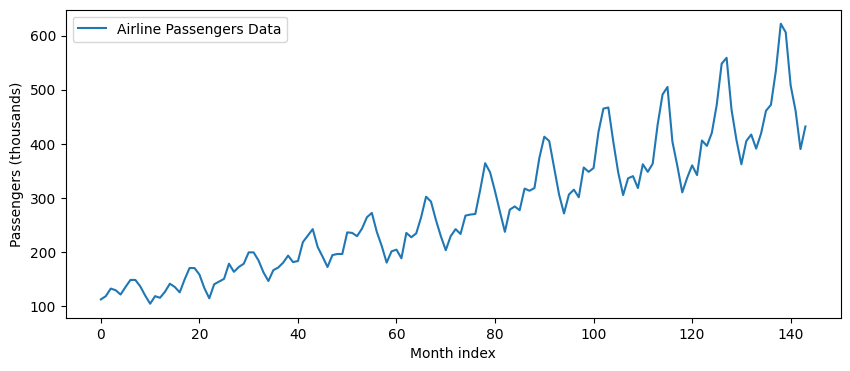

In [3]:
training_set = pd.read_csv('data/airline-passengers.csv')
#training_set = pd.read_csv('data/shampoo.csv')

# keep only the value column -> numpy array of shape (144, 1)
training_set = training_set.iloc[:, 1:2].values

plt.figure(figsize=(10, 4))
plt.plot(training_set, label='Airline Passengers Data')
plt.xlabel('Month index')
plt.ylabel('Passengers (thousands)')
plt.legend()
plt.show()

<a name='2'></a>
## 2 - Preparing the Data

An LSTM doesn't consume a raw series directly - you first have to turn forecasting into a **supervised learning** problem. Three steps:

<a name='2-1'></a>
### 2.1 - Scaling

Neural networks train much better when inputs are small and centered. `MinMaxScaler` maps the series into $[0, 1]$:

$$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

Keep the fitted scaler around (`sc`) - you'll need `sc.inverse_transform` later to map predictions back to real passenger counts.

<a name='2-2'></a>
### 2.2 - Sliding Windows

To create input/target pairs, slide a window of length `seq_length` over the series: the window is the input $x$, and the very next value is the target $y$.

With `seq_length = 4`:

```
series:  s0  s1  s2  s3  s4  s5  s6 ...

x = [s0, s1, s2, s3]   ->   y = s4
x = [s1, s2, s3, s4]   ->   y = s5
x = [s2, s3, s4, s5]   ->   y = s6
...
```

So the model learns: *"given the last 4 months, predict the next one."*

<a name='2-3'></a>
### 2.3 - Train / Test Split

The first 67% of windows are used for training and the rest for testing. Note that the split is **chronological, not random** - shuffling would leak future information into the training set and make the test score meaningless.

In [4]:
def sliding_windows(data, seq_length):
    """Turn a series into (windows, next-value) supervised pairs.

    Returns:
        x -- shape (num_samples, seq_length, 1), the input windows
        y -- shape (num_samples, 1), the value right after each window
    """
    x = []
    y = []

    for i in range(len(data) - seq_length - 1):
        _x = data[i:(i + seq_length)]   # window of seq_length values
        _y = data[i + seq_length]       # the value to predict
        x.append(_x)
        y.append(_y)

    return np.array(x), np.array(y)


# scale the series into [0, 1]
sc = MinMaxScaler()
training_data = sc.fit_transform(training_set)

# build the supervised samples
seq_length = 4
x, y = sliding_windows(training_data, seq_length)

# chronological 67/33 split
train_size = int(len(y) * 0.67)
test_size = len(y) - train_size

# full set (used later to plot predictions over the whole series)
dataX = torch.Tensor(x)
dataY = torch.Tensor(y)

trainX = torch.Tensor(x[0:train_size])
trainY = torch.Tensor(y[0:train_size])

testX = torch.Tensor(x[train_size:])
testY = torch.Tensor(y[train_size:])

print('dataX :', dataX.shape, '  (samples, seq_length, features)')
print('trainX:', trainX.shape)
print('testX :', testX.shape)

dataX : torch.Size([139, 4, 1])   (samples, seq_length, features)
trainX: torch.Size([93, 4, 1])
testX : torch.Size([46, 4, 1])


<a name='3'></a>
## 3 - The LSTM Model

The model is deliberately tiny: one LSTM layer with just **2 hidden units**, followed by a linear layer that maps the hidden state to the prediction.

<img src="images/lstm_time_series_model.png" style="width:750px;">
<caption><center><font color='purple'><b>Figure 1</b>: The model, unrolled over one input window. Starting from zero states, the LSTM reads the 4-month window one value at a time, carrying its cell state $c^{\langle t \rangle}$ and hidden state $a^{\langle t \rangle}$ forward. Only the <b>final</b> hidden state $h_n$ is passed to the linear layer, which predicts the next month.</font></center></caption>

**How the shapes flow** (with `batch_first=True`):

| tensor | shape | meaning |
|---|---|---|
| input `x` | `(batch, seq_length, input_size)` | a batch of windows, 1 feature per time step |
| `output` | `(batch, seq_length, hidden_size)` | the hidden state $a^{\langle t \rangle}$ at *every* time step |
| `h_n` | `(num_layers, batch, hidden_size)` | the hidden state after the *last* time step, per layer |
| `c_n` | `(num_layers, batch, hidden_size)` | the cell state after the last time step, per layer |

For one-step-ahead forecasting only the **last** time step matters: after the LSTM has read the whole window, its final hidden state `h_n[-1]` (the last layer's summary of the window) is fed to `nn.Linear` to produce the prediction.

The initial hidden and cell states $a^{\langle 0 \rangle}, c^{\langle 0 \rangle}$ are set to zeros - this is also what PyTorch does by default if you don't pass them, but it's spelled out here to make the recurrence explicit.

In [5]:
class LSTM(nn.Module):

    def __init__(self, num_classes, input_size, hidden_size, num_layers):
        super(LSTM, self).__init__()

        self.num_classes = num_classes    # size of the output (1 value to predict)
        self.num_layers = num_layers      # number of stacked LSTM layers
        self.input_size = input_size      # features per time step (1: just the passenger count)
        self.hidden_size = hidden_size    # units in the LSTM hidden state

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True)

        # maps the final hidden state to the predicted value
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # initial hidden and cell states: zeros, shape (num_layers, batch, hidden_size)
        h_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        # propagate the whole window through the LSTM
        output, (h_n, c_n) = self.lstm(x, (h_0, c_0))

        # h_n[-1]: last layer's hidden state after reading the full window -> (batch, hidden_size)
        out = self.fc(h_n[-1])

        return out

<a name='4'></a>
## 4 - Training

This is a regression problem, so the loss is **mean squared error**:

$$\mathcal{L} = \frac{1}{m}\sum_{i=1}^{m}\left(\hat{y}^{(i)} - y^{(i)}\right)^2$$

The dataset is tiny (95 training windows), so there's no need for mini-batches - every step is **full-batch gradient descent** with the Adam optimizer:

1. forward pass on all of `trainX`
2. compute the MSE against `trainY`
3. backpropagate and update the weights

2000 epochs sounds like a lot, but with ~100 samples and ~50 parameters it runs in seconds.

In [6]:
num_epochs = 2000
learning_rate = 0.01

input_size = 1     # one feature per time step
hidden_size = 2    # tiny hidden state is enough for this series
num_layers = 1

num_classes = 1    # predict a single value

lstm = LSTM(num_classes, input_size, hidden_size, num_layers)

criterion = torch.nn.MSELoss()    # mean-squared error for regression
optimizer = torch.optim.Adam(lstm.parameters(), lr=learning_rate)
#optimizer = torch.optim.SGD(lstm.parameters(), lr=learning_rate)

# Train the model (full-batch: the whole training set every epoch)
for epoch in range(num_epochs):
    outputs = lstm(trainX)
    optimizer.zero_grad()

    # obtain the loss function
    loss = criterion(outputs, trainY)

    loss.backward()      # compute gradients
    optimizer.step()     # update the weights

    if epoch % 100 == 0:
        print("Epoch: %d, loss: %1.5f" % (epoch, loss.item()))

Epoch: 0, loss: 0.03006


Epoch: 100, loss: 0.00529
Epoch: 200, loss: 0.00241


Epoch: 300, loss: 0.00182
Epoch: 400, loss: 0.00170


Epoch: 500, loss: 0.00169
Epoch: 600, loss: 0.00168


Epoch: 700, loss: 0.00166
Epoch: 800, loss: 0.00164
Epoch: 900, loss: 0.00162


Epoch: 1000, loss: 0.00160
Epoch: 1100, loss: 0.00159
Epoch: 1200, loss: 0.00158


Epoch: 1300, loss: 0.00158
Epoch: 1400, loss: 0.00157
Epoch: 1500, loss: 0.00157


Epoch: 1600, loss: 0.00156
Epoch: 1700, loss: 0.00156


Epoch: 1800, loss: 0.00155


Epoch: 1900, loss: 0.00155


<a name='4-1'></a>
### 4.1 - Counting the Parameters

How big is this model, really? You can count by hand. An LSTM has **4 gates** (forget, update, candidate/$\tilde{c}$, output), and each gate has a weight matrix for the input, a weight matrix for the hidden state, and biases:

$$\underbrace{4 \times \big( \text{hidden} \times \text{input} \big)}_{W_{ih}} \;+\; \underbrace{4 \times \big( \text{hidden} \times \text{hidden} \big)}_{W_{hh}} \;+\; \underbrace{2 \times 4 \times \text{hidden}}_{b_{ih},\, b_{hh}}$$

(PyTorch stores **two** bias vectors per gate, $b_{ih}$ and $b_{hh}$ - mathematically they just add up, it's a CuDNN-compatibility detail.)

With `input_size = 1` and `hidden_size = 2`:

* LSTM: $4 \times (2 \times 1) + 4 \times (2 \times 2) + 2 \times 4 \times 2 = 8 + 16 + 16 = 40$
* Linear head: $2 \times 1 + 1 = 3$
* **Total: 43 parameters**

Compare that with the ~50 windows-worth of numbers the model is trained on - this model is tiny, which is exactly why it doesn't need much data or regularization. The cell below verifies the count directly from `lstm.named_parameters()`.

In [7]:
# per-tensor breakdown of the model's parameters
total = 0
for name, param in lstm.named_parameters():
    print(f'{name:22s} shape {str(tuple(param.shape)):8s} -> {param.numel():3d} params')
    total += param.numel()

print('-' * 50)
print(f'total trainable parameters: {total}')

# sanity check against the hand-derived formula
lstm_params = 4 * hidden_size * input_size + 4 * hidden_size * hidden_size + 2 * 4 * hidden_size
fc_params = hidden_size * num_classes + num_classes
assert total == lstm_params + fc_params
print(f'formula: LSTM {lstm_params} + Linear {fc_params} = {lstm_params + fc_params}  ✓')

lstm.weight_ih_l0      shape (8, 1)   ->   8 params
lstm.weight_hh_l0      shape (8, 2)   ->  16 params
lstm.bias_ih_l0        shape (8,)     ->   8 params
lstm.bias_hh_l0        shape (8,)     ->   8 params
fc.weight              shape (1, 2)   ->   2 params
fc.bias                shape (1,)     ->   1 params
--------------------------------------------------
total trainable parameters: 43
formula: LSTM 40 + Linear 3 = 43  ✓


<a name='5'></a>
## 5 - Evaluation

To judge the model, run it over **all** windows (train + test) and plot predictions against the true series:

* `lstm.eval()` + `torch.no_grad()` switch off training behaviour and gradient tracking
* predictions are in the scaled $[0,1]$ space, so `sc.inverse_transform` maps them back to real passenger counts
* the **red dashed line** marks the train/test boundary - everything to its right was never seen during training

A useful single number is the **RMSE** (root mean squared error), which is in the same units as the data (thousands of passengers).

Train RMSE: 20.29
Test  RMSE: 52.52


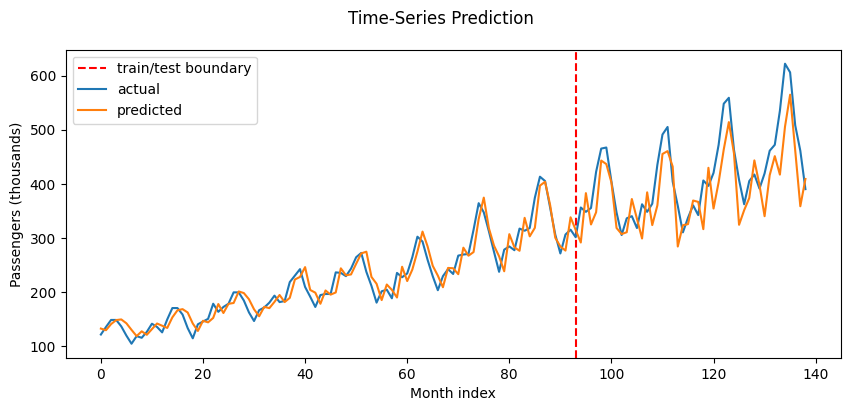

In [8]:
lstm.eval()
with torch.no_grad():
    train_predict = lstm(dataX)   # predictions for every window in the series

data_predict = train_predict.numpy()
dataY_plot = dataY.numpy()

# back to the original scale (thousands of passengers)
data_predict = sc.inverse_transform(data_predict)
dataY_plot = sc.inverse_transform(dataY_plot)

# RMSE in real units, separately for the seen and unseen parts
train_rmse = np.sqrt(np.mean((data_predict[:train_size] - dataY_plot[:train_size]) ** 2))
test_rmse = np.sqrt(np.mean((data_predict[train_size:] - dataY_plot[train_size:]) ** 2))
print('Train RMSE: %.2f' % train_rmse)
print('Test  RMSE: %.2f' % test_rmse)

plt.figure(figsize=(10, 4))
plt.axvline(x=train_size, c='r', linestyle='--', label='train/test boundary')

plt.plot(dataY_plot, label='actual')
plt.plot(data_predict, label='predicted')
plt.xlabel('Month index')
plt.ylabel('Passengers (thousands)')
plt.suptitle('Time-Series Prediction')
plt.legend()
plt.show()

<a name='6'></a>
## 6 - Things to Try

The whole pipeline is a handful of knobs - experimenting with them is the best way to build intuition:

* **`seq_length`** - the model currently only sees 4 months of history, less than one seasonal cycle. Does `seq_length = 12` (a full year) help the test RMSE?
* **`hidden_size`** - 2 units is extreme. Try 10 or 50: does the train loss drop? Does the *test* RMSE follow, or does the model start to overfit?
* **`num_layers`** - stack 2 LSTM layers. Note the model code needs no changes: `h_n[-1]` already picks the last layer's hidden state.
* **the other dataset** - swap in the shampoo sales series (the commented-out lines in sections 1 and 2). It's shorter and noisier; how does the model cope?
* **a proper baseline** - before trusting any forecast model, compare it against predicting "next month = this month" (naive persistence). Compute that baseline's RMSE on the test set - does the LSTM actually beat it?